# Phase 2 — Video Exploration

**Fight:** Islam Makhachev vs Alexander Volkanovski 1 (UFC)

Goal: understand the video I'm working with — its format, duration, and what frames actually look like — before I design any detection logic.

I deliberately keep the heavy lifting in `src/video/loader.py` so this notebook stays focused on *exploration* and the reusable code can be unit-tested and reused in later phases.

In [1]:
import sys
from pathlib import Path

# Find the project root by walking up until I find the src/ package.
# This works whether the kernel starts in the repo root or in notebooks/.
def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "requirements.txt").is_file():
            return parent
    raise RuntimeError("Could not locate project root (src/ + requirements.txt)")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.video.loader import video_metadata, frame_at_second, bgr_to_rgb

VIDEO = REPO_ROOT / "data/raw/Watch Islam Makhachev vs Alexander Volkanovski 1 UFC.mp4"
LABELS = REPO_ROOT / "notebooks/Makhachev_vs_Volkanovski_1_manual_data.csv"
print(VIDEO.resolve(), "exists:", VIDEO.exists())
print(LABELS.resolve(), "exists:", LABELS.exists())

C:\Users\DanielDignam\Desktop\FightSmart\data\raw\Watch Islam Makhachev vs Alexander Volkanovski 1 UFC.mp4 exists: True
C:\Users\DanielDignam\Desktop\FightSmart\notebooks\Makhachev_vs_Volkanovski_1_manual_data.csv exists: True


## 1. Video metadata

The first question is simply: **what am I processing?** Resolution, framerate, and duration drive every downstream decision (memory, processing time, frame-sampling strategy).

In [2]:
meta = video_metadata(VIDEO)
for k, v in meta.items():
    print(f"{k:14}: {v}")

path          : C:\Users\DanielDignam\Desktop\FightSmart\data\raw\Watch Islam Makhachev vs Alexander Volkanovski 1 UFC.mp4
fps           : 30.0
frame_count   : 65162
width         : 1920
height        : 1080
duration_s    : 2172.07
duration_min  : 36.2
codec         : h264


### Why these numbers matter
- **1920×1080 at 30 fps** → 65,162 frames. Analyzing *every* frame is expensive (and mostly redundant — adjacent frames are nearly identical).
- **36 minutes** is longer than the 15 minutes of fighting (3 rounds × 5 min) because it includes walkouts, intros, and rest between rounds.
- Key design question: **how many frames per second do I actually need?** A knockdown, takedown, or big exchange lasts well over a second, so I can afford to sample at a low rate (e.g. 1–5 fps) and still capture events. Sampling at 5 fps cuts 65k frames to ~10.8k — a 6× reduction in compute with almost no loss for my use case.

In [3]:
fps = meta["fps"]
for rate in (30, 5, 2, 1):
    n = int(meta["duration_s"] * rate)
    print(f"sampling at {rate:>2} fps -> ~{n:>7,} frames  (vs {meta['frame_count']:,} at native)")

sampling at 30 fps -> ~ 65,162 frames  (vs 65,162 at native)
sampling at  5 fps -> ~ 10,860 frames  (vs 65,162 at native)
sampling at  2 fps -> ~  4,344 frames  (vs 65,162 at native)
sampling at  1 fps -> ~  2,172 frames  (vs 65,162 at native)


## 2. What does a frame look like?

I'll sample frames on a regular interval to get a feel for the broadcast: the cage setup, fighters, graphics overlays, and round timers. I show one frame every 60 seconds of the first 10 minutes.

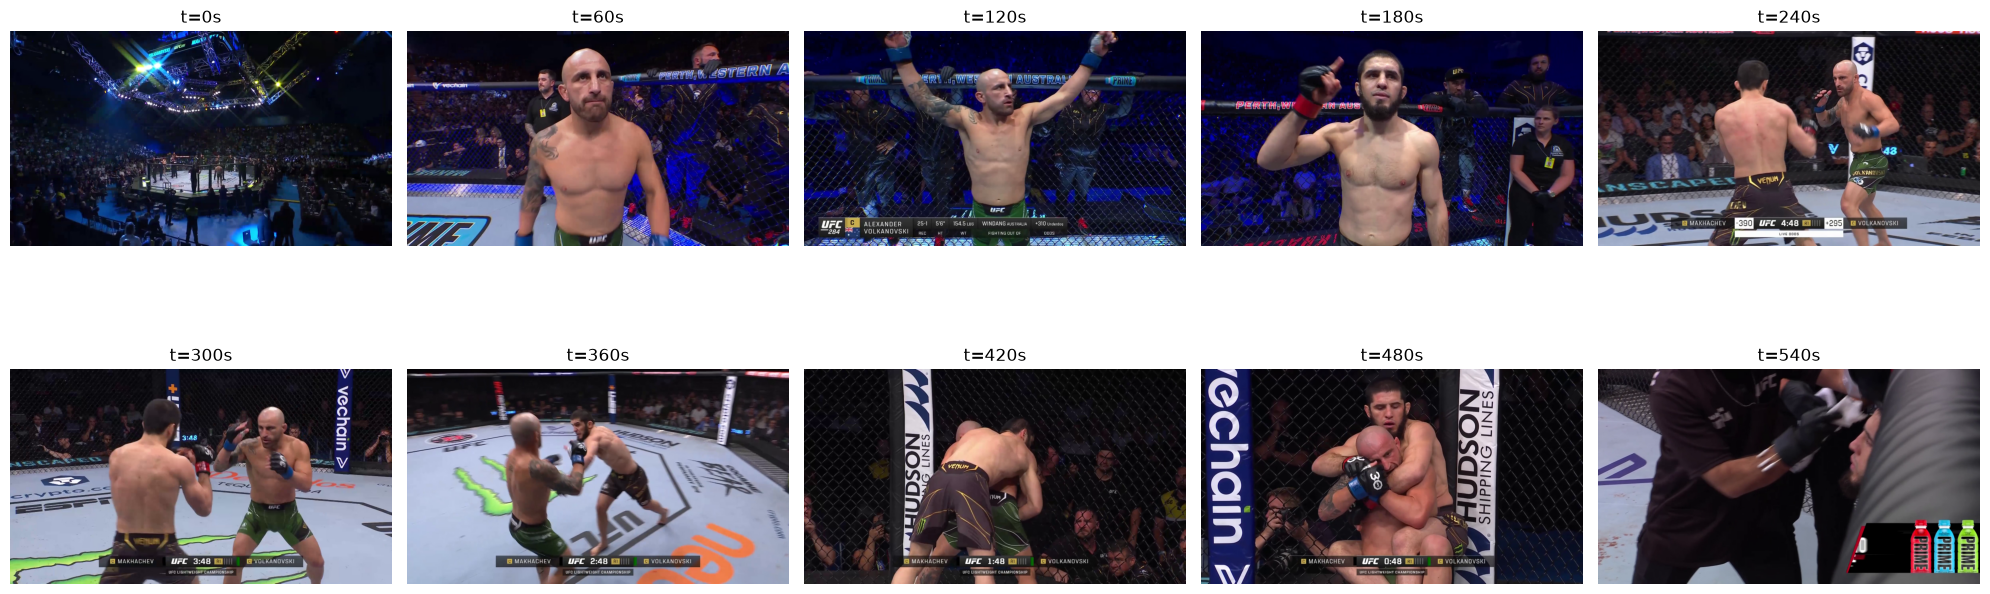

In [4]:
plt.rcParams["figure.figsize"] = (16, 9)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, second in enumerate(range(0, 600, 60)):
    frame = frame_at_second(VIDEO, second)
    ax = axes[i // 5][i % 5]
    ax.imshow(bgr_to_rgb(frame))
    ax.set_title(f"t={second}s")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Observations to record (fill these in from what you see)
- Fixed camera or cuts? Is the broadcast a single locked-off cage view, or does it cut between angles? (This changes how I measure motion — cuts create huge frame differences that are *not* fight action.)
- What static graphics are overlaid (round timer, score)?
- Is there a consistent cage/canvas region where fighters appear? (Later I'll use a spatial grid like my dissertation's 5×5 approach.)

## 3. Frames at known highlight moments

Now I connect the exploration to my **ground-truth labels**. The manual CSV records real events with timestamps. Let me look at frames around a few of the biggest ones — this is how I start to reason about what "a highlight looks like" in pixels.

Ground-truth events I'll inspect (round 1): the fight start, the knockdown, the takedown, and the round-1 end.

In [5]:
df = pd.read_csv(LABELS)
df = df.dropna(subset=["VIDEO_TIME"])  # drop empty trailing rows
df.head(15)

,ROUND,VIDEO_TIME,EVENT_TYPE,DESC,NOTE,CONFIDENCE
0,0.0,3:46,fight_start,fight begins,start of event timeline,high
1,1.0,4:35,significant_strike,body kick,"clean, open",high
2,1.0,4:45-4:48,combination,"right to body, left hook",combo used often,high
3,1.0,5:28-5:29,combination,right hook + left straight,"same combo, off of stance switch",high
4,1.0,5:57,counter_attack,"block then, left hook",oppenent reacts from previous combo,medium
5,1.0,6:33,significant_stike,body kick,open,medium
6,1.0,6:38,knockdown,left hook off of exchange,"V steps in on leaping jab, M steps back into e...",high
7,1.0,6:39,blocked_strike,head kick,"V is rocked, M lands right high kick",high
8,1.0,6:41,significant_strike,right knee,"V level changed, M reacts with knee to head",high
9,1.0,6:42,takedown_attempt,clinch off of knee,M goes for takedown off of fence after clinch,high


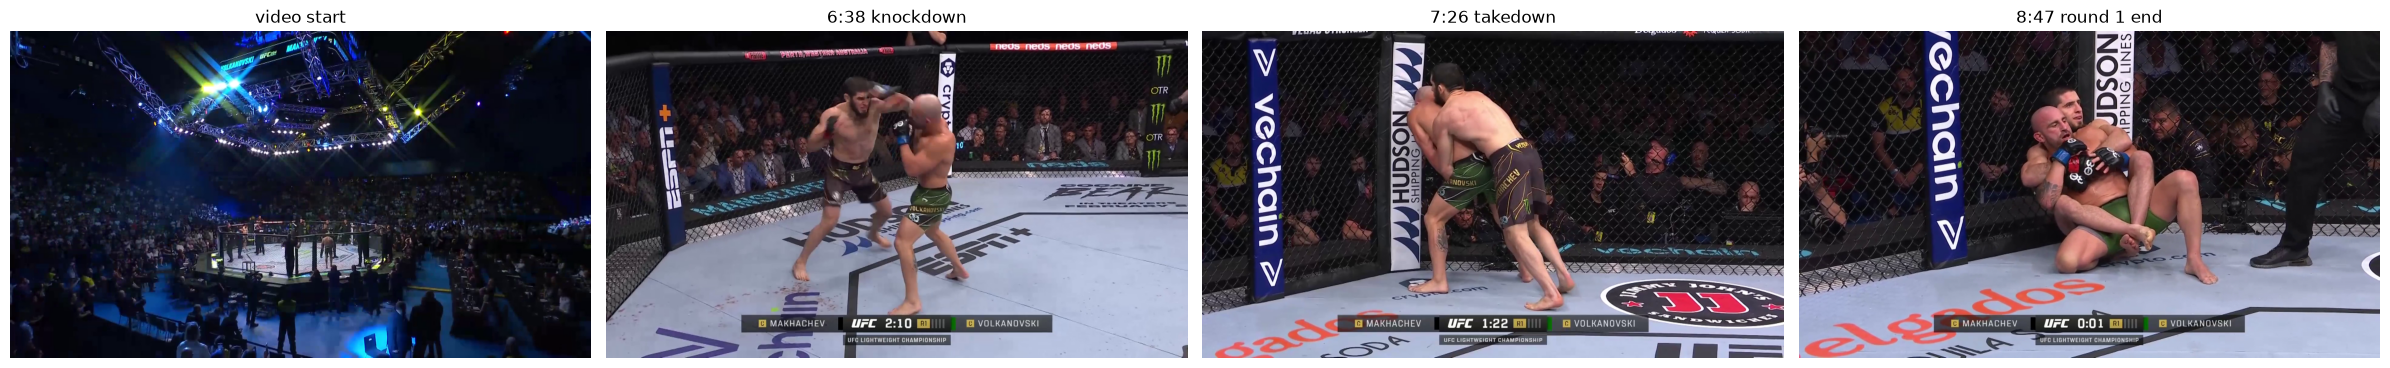

In [6]:
# Show frames at a few landmark events from the manual labels.
# Each entry: (label_time, title)
landmarks = [
    (0, "video start"),
    (398, "6:38 knockdown"),
    (446, "7:26 takedown"),
    (527, "8:47 round 1 end"),
]

fig, axes = plt.subplots(1, len(landmarks), figsize=(24, 7))
for ax, (second, title) in zip(axes, landmarks):
    frame = frame_at_second(VIDEO, second)
    ax.imshow(bgr_to_rgb(frame))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Notes for the pipeline design
- These frames confirm the broadcast layout. Note the round timer graphic and camera position.
- The **knockdown at 6:38** and **takedown at 7:26** should be moments of high *motion* and *composition change* — candidates I'll want my rule-based detector to flag. I can check later whether motion features actually spike there (Phase 4).
- Next step for Phase 2/3: extract **frame-difference (motion) features** over time and an **audio energy** trace, then overlay them against these labelled events to see which signals best separate highlights from the rest.